In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
train.shape

(891, 12)

In [5]:
test.shape

(418, 11)

In [6]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [12]:
#calculating the percentage of missing values in each column

missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100
pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent})


,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [13]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [15]:
train["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

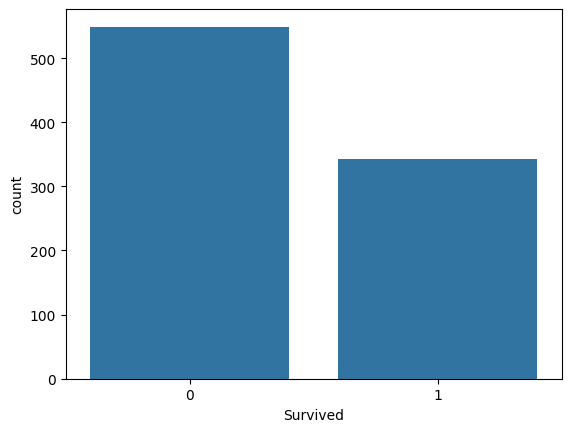

In [16]:
sns.countplot(data=train, x="Survived")
plt.show()

In [17]:
pd.crosstab(
    train["Sex"],
    train["Survived"],
    normalize="index"
)

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


<Axes: xlabel='Pclass', ylabel='count'>

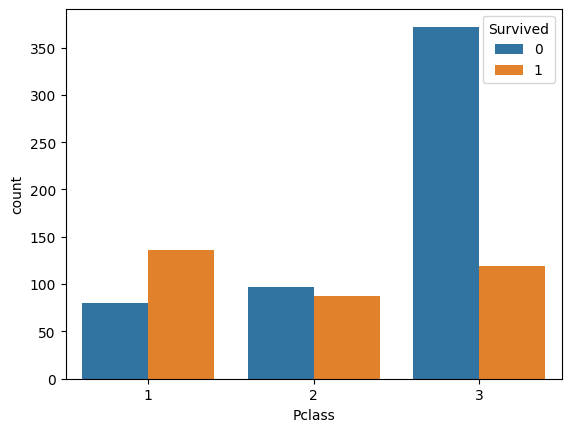

In [18]:
sns.countplot(data=train, x="Pclass", hue="Survived")

In [19]:
pd.crosstab(
    train["Pclass"],
    train["Survived"],
    normalize="index"
)

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


In [21]:
pd.crosstab(
    [train["Pclass"],train["Sex"]],
    train["Survived"],
    normalize="index"
)

Survived              0         1
Pclass Sex                       
1      female  0.031915  0.968085
       male    0.631148  0.368852
2      female  0.078947  0.921053
       male    0.842593  0.157407
3      female  0.500000  0.500000
       male    0.864553  0.135447

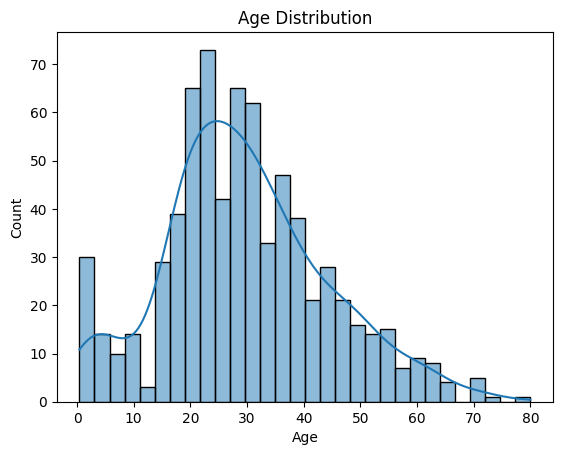

In [22]:
sns.histplot(
    data=train,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

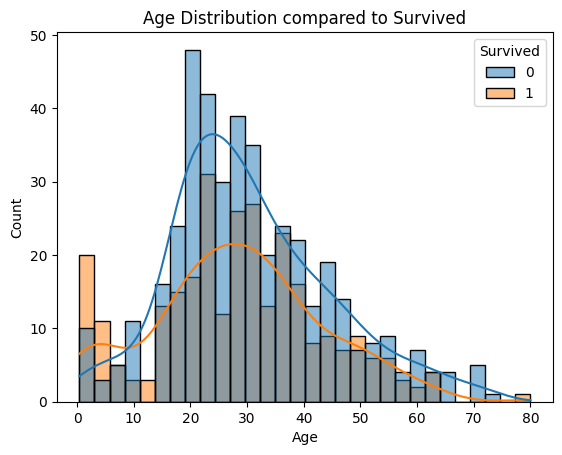

In [23]:
sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)

plt.title("Age Distribution compared to Survived")
plt.show()

In [24]:
train.groupby("Survived")["Age"].agg( ["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
Survived,,,,,
0,424,30.626179,28.0,1.00,74.0
1,290,28.343690,28.0,0.42,80.0


In [25]:
train["Child"]= train["Age"]<18

In [26]:
pd.crosstab(train["Child"], train["Survived"], normalize="index")

Survived,0,1
Child,,
False,0.638817,0.361183
True,0.460177,0.539823


In [27]:
train["Embarked"] = train["Embarked"].fillna(
    train["Embarked"].mode()[0]
)

In [28]:
train["Age"]=train["Age"].fillna(train["Age"].median())

In [29]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
 12  Child        891 non-null    bool   
dtypes: bool(1), float64(2), int64(5), str(5)
memory usage: 84.5 KB


In [30]:
train["Deck"] = train["Cabin"].str[0]

In [31]:
train[["Cabin", "Deck"]].head(10)

,Cabin,Deck
0,NaN,NaN
1,C85,C
2,NaN,NaN
3,C123,C
4,NaN,NaN
5,NaN,NaN
6,E46,E
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [32]:
train["Deck"] = train["Deck"].fillna("Unknown")

In [33]:
train["FamilySize"]=train["SibSp"] + train["Parch"] + 1

In [34]:
train["IsAlone"] = (train["FamilySize"] == 1).astype(int)

In [35]:
train["Name"].head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: str

In [36]:
train["Title"] = train["Name"].str.extract(
    r",\s*([^.]*)\."
)

In [37]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Child            0
Deck             0
FamilySize       0
IsAlone          0
Title            0
dtype: int64

In [38]:
train = train.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"]
)

In [39]:
train.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Child         0
Deck          0
FamilySize    0
IsAlone       0
Title         0
dtype: int64

In [40]:
print(train["Sex"].unique())
print(train["Embarked"].unique())
print(train["Deck"].unique())
print(train["Title"].unique())

<StringArray>
['male', 'female']
Length: 2, dtype: str
<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str
<StringArray>
['Unknown', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str
<StringArray>
[          'Mr',          'Mrs',         'Miss',       'Master',
          'Don',          'Rev',           'Dr',          'Mme',
           'Ms',        'Major',         'Lady',          'Sir',
         'Mlle',          'Col',         'Capt', 'the Countess',
     'Jonkheer']
Length: 17, dtype: str


In [41]:
title_counts = train["Title"].value_counts()

rare_titles = title_counts[title_counts < 10].index

train["Title"] = train["Title"].replace(
    rare_titles,
    "Rare"
)

In [42]:
train["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [43]:
train = pd.get_dummies(
    train,
    columns=["Sex", "Embarked", "Deck", "Title"],
    drop_first=True,
    dtype=int
)

In [44]:
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Child,FamilySize,IsAlone,Sex_male,...,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,1,0,7.2500,False,2,0,1,...,0,0,0,0,0,1,0,1,0,0
1,1,1,38.0,1,0,71.2833,False,2,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1,3,26.0,0,0,7.9250,False,1,1,0,...,0,0,0,0,0,1,1,0,0,0
3,1,1,35.0,1,0,53.1000,False,2,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,3,35.0,0,0,8.0500,False,1,1,1,...,0,0,0,0,0,1,0,1,0,0


In [45]:
X = train.drop("Survived", axis=1)
y = train["Survived"]

In [46]:
print(X.shape)
print(y.shape)

(891, 23)
(891,)


In [47]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Child,FamilySize,IsAlone,Sex_male,Embarked_Q,...,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,1,0,7.2500,False,2,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,1,38.0,1,0,71.2833,False,2,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,3,26.0,0,0,7.9250,False,1,1,0,0,...,0,0,0,0,0,1,1,0,0,0
3,1,35.0,1,0,53.1000,False,2,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,3,35.0,0,0,8.0500,False,1,1,1,0,...,0,0,0,0,0,1,0,1,0,0


In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
model= LogisticRegression(max_iter=1000)

In [52]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [54]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8156


In [55]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[88 17]
 [16 58]]


Text(50.722222222222214, 0.5, 'Actual')

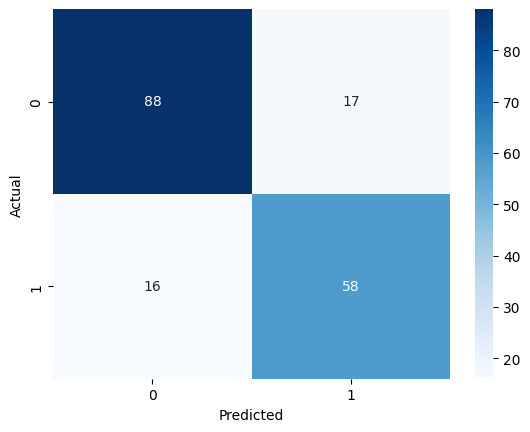

In [56]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [57]:
classification_rep = classification_report(y_test, y_pred)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       105
           1       0.77      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [59]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7988826815642458


In [62]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

In [63]:
importance = importance.sort_values("Importance",ascending=False)

In [64]:
print(importance)

         Feature  Importance
4           Fare    0.208141
1            Age    0.189707
20      Title_Mr    0.131160
8       Sex_male    0.101763
0         Pclass    0.059199
6     FamilySize    0.046761
21     Title_Mrs    0.042891
2          SibSp    0.033535
19    Title_Miss    0.033224
18  Deck_Unknown    0.031356
3          Parch    0.022207
10    Embarked_S    0.021029
5          Child    0.013666
14        Deck_E    0.011423
9     Embarked_Q    0.010384
7        IsAlone    0.010095
11        Deck_B    0.009657
12        Deck_C    0.007528
13        Deck_D    0.006291
22    Title_Rare    0.005600
16        Deck_G    0.002208
15        Deck_F    0.001950
17        Deck_T    0.000222


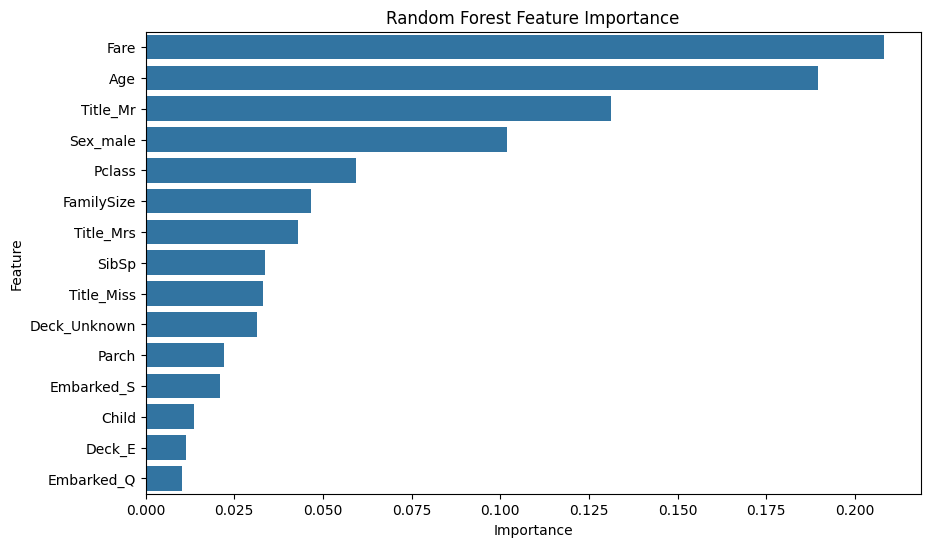

In [65]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

In [66]:
from sklearn.model_selection import cross_val_score

In [67]:
log_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression scores:", log_scores)
print("Mean:", log_scores.mean())

Logistic Regression scores: [0.81564246 0.82022472 0.80898876 0.8258427  0.85393258]
Mean: 0.8249262444291006


In [68]:
rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Random Forest scores:", rf_scores)
print("Mean:", rf_scores.mean())

Random Forest scores: [0.81005587 0.78651685 0.85955056 0.75280899 0.8258427 ]
Mean: 0.8069549934090766


In [70]:
num_cols = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_pipe = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])

In [73]:
scaled_scores = cross_val_score(
    log_pipe,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Scores:", scaled_scores)
print("Mean:", scaled_scores.mean())

Scores: [0.82122905 0.82022472 0.79213483 0.81460674 0.85955056]
Mean: 0.8215491808423827


In [74]:
LogisticRegression(C=1)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [75]:
C = [0.001, 0.01, 0.1, 1, 10, 100]

In [76]:
from sklearn.model_selection import GridSearchCV

In [77]:
log_model = LogisticRegression(max_iter=1000)

In [78]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

In [79]:
grid.fit(X, y)

c:\Users\PRACHITA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\PRACHITA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    htt

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate p

In [80]:
print("Best parameters:", grid.best_params_)

Best parameters: {'C': 1}


In [81]:
print("Best model:", grid.best_estimator_)

Best model: LogisticRegression(C=1, max_iter=1000)


In [82]:
test = pd.read_csv("test.csv")

In [83]:
passenger_ids = test["PassengerId"]

In [84]:
test["Embarked"] = test["Embarked"].fillna(
    test["Embarked"].mode()[0]
)

In [85]:
test["Age"] = test.groupby(
    ["Pclass", "Sex"]
)["Age"].transform(
    lambda x: x.fillna(x.median())
)

In [86]:
test["Deck"] = test["Cabin"].str[0]
test["Deck"] = test["Deck"].fillna("Unknown")

In [87]:
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

In [88]:
test["IsAlone"] = (test["FamilySize"] == 1).astype(int)

In [89]:
test["Title"] = test["Name"].str.extract(
    r",\s*([^.]*)\."
)

In [90]:
test["Title"] = test["Name"].str.extract(
    r",\s*([^.]*)\."
)

In [93]:
test["Title"] = test["Title"].replace(
    rare_titles,
    "Rare"
)

In [94]:
test = test.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"]
)

In [95]:
test = pd.get_dummies(
    test,
    columns=["Sex", "Embarked", "Deck", "Title"],
    drop_first=True,
    dtype=int
)

In [96]:
test = test.reindex(
    columns=X.columns,
    fill_value=0
)
print(X.shape)
print(test.shape)

(891, 23)
(418, 23)


In [97]:
final_model = LogisticRegression(
    C=1,
    max_iter=1000
)

In [98]:
final_model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [100]:
test.isnull().sum()

Pclass          0
Age             0
SibSp           0
Parch           0
Fare            1
Child           0
FamilySize      0
IsAlone         0
Sex_male        0
Embarked_Q      0
Embarked_S      0
Deck_B          0
Deck_C          0
Deck_D          0
Deck_E          0
Deck_F          0
Deck_G          0
Deck_T          0
Deck_Unknown    0
Title_Miss      0
Title_Mr        0
Title_Mrs       0
Title_Rare      0
dtype: int64

In [101]:
test["Fare"] = test["Fare"].fillna(
    train["Fare"].median()
)

In [102]:
test_pred = final_model.predict(test)

In [103]:
print(test_pred[:20])
print(len(test_pred))

[0 1 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1]
418


In [104]:
submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": test_pred
})

In [105]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [106]:
submission.to_csv(
    "submission.csv",
    index=False
)

In [107]:
submission.shape

(418, 2)

In [108]:
submission.shape

(418, 2)

In [109]:
print(submission.isnull().sum())
print(submission["Survived"].value_counts())

PassengerId    0
Survived       0
dtype: int64
Survived
0    253
1    165
Name: count, dtype: int64
